<a href="https://colab.research.google.com/github/iweam/genai-bootcamp/blob/main/W3S3_Lab_Whisper_Transcription.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#16304A 0%,#003C9C 100%);border-radius:14px;padding:22px 26px;color:#fff;font-family:Segoe UI,Arial,sans-serif;">
  <div style="display:flex;justify-content:space-between;align-items:center;gap:16px;">
    <div>
      <div style="font-size:13px;letter-spacing:1px;opacity:.85;text-transform:uppercase;">Generative AI Summer Bootcamp &middot; Najran University</div>
      <div style="font-size:26px;font-weight:800;margin-top:4px;">Lab — Whisper Speech-to-Text → Summary</div>
      <div style="font-size:15px;opacity:.92;margin-top:4px;">Week 3 · Session 3 — Audio & Speech AI</div>
    </div>
    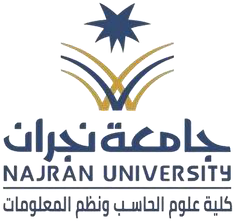
  </div>
  <div style="margin-top:16px;display:flex;gap:10px;flex-wrap:wrap;font-size:13px;">
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">🏆 NCA-GENM track</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">⏱️ Lab: ≈ 50 minutes</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">▶️ Runs on Google Colab (free)</span>
  </div>
</div>

<a target="_blank" href="https://colab.research.google.com/"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:16px;margin-bottom:6px;">🎓 Learning objectives</div>
<ul style="margin:0;padding-left:20px;font-size:15px;color:#16304A;"><li style="margin:5px 0;">Load a short public audio clip and inspect its <b>sample rate</b> and duration.</li>
<li style="margin:5px 0;">Transcribe speech to text with <b>openai/whisper-base</b> via the transformers pipeline.</li>
<li style="margin:5px 0;"><b>Chain</b> it: summarize the transcript with <b>Qwen2.5-1.5B-Instruct</b> (audio → transcript → summary).</li>
<li style="margin:5px 0;">(Optional) Turn text back into speech with a small open <b>TTS</b> model.</li></ul></div>

## How to use this notebook

Run the cells **in order**, top to bottom (`Shift+Enter`). Each part starts with a short note that connects the code back to today's slides. Everything here uses **open, ungated** models — no login, no API key, no token.

<div style="border:1px solid #16304A33;border-left:6px solid #16304A;background:#EDF1F6;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#16304A;font-size:15px;margin-bottom:4px;">🔧 First: turn on the free GPU</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Click <b>Runtime → Change runtime type → T4 GPU → Save</b>. Whisper-base and Qwen-1.5B both fit comfortably in the free T4's ~15 GB. It runs on CPU too, just much slower.</div></div>

### Setup
Colab already includes PyTorch. We add Transformers plus the audio helpers (`datasets`, `soundfile`, `librosa`) used to load and decode audio. If pip prints any red dependency warnings, you can safely ignore them.

In [1]:
# One-time setup (~30-60 seconds)
!pip -q install -U "transformers>=4.56,<6" accelerate "datasets>=4,<6" soundfile librosa sentencepiece

# Keep the lab output clean (hides harmless library deprecation notices)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

print("Setup complete — now run the cells below in order.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.5 MB/s eta 0:00:00
Setup complete — now run the cells below in order.


In [2]:
import torch
GPU = torch.cuda.is_available()
print("GPU available:", GPU)
print("Device:", torch.cuda.get_device_name(0) if GPU else "CPU (works, but Part 3 will take a few minutes per answer)")

GPU available: True
Device: Tesla T4


## Part 1 — Get a short audio clip

We download a tiny, public speech sample (a single spoken sentence from the LibriSpeech *dummy* dataset on the Hugging Face Hub) and save it as a `.wav` file. It is already **16 kHz mono** — exactly what Whisper expects, as we saw on the slides.

In [3]:
from datasets import load_dataset
import soundfile as sf

# small, ungated sample dataset (downloads in a couple of seconds)
ds = load_dataset("hf-internal-testing/librispeech_asr_dummy", "clean", split="validation")

sample = ds[0]
audio = sample["audio"]            # audio["array"] = samples, audio["sampling_rate"] = Hz
sf.write("sample.wav", audio["array"], audio["sampling_rate"])

duration = len(audio["array"]) / audio["sampling_rate"]
print("Saved sample.wav")
print(f"Sampling rate : {audio['sampling_rate']} Hz")
print(f"Duration      : {duration:.2f} seconds")
print(f"Samples       : {len(audio['array']):,} numbers")
print(f"Reference text: {sample['text']!r}")

README.md:   0%|          | 0.00/520 [00:00<?, ?B/s]

clean/validation-00000-of-00001.parquet:   0%|          | 0.00/9.19M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/73 [00:00<?, ? examples/s]

Saved sample.wav
Sampling rate : 16000 Hz
Duration      : 5.86 seconds
Samples       : 93,680 numbers
Reference text: 'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL'


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ Why 16,000 Hz?</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Whisper was trained on <b>16 kHz mono</b> audio, so the pipeline resamples anything else to 16 kHz for you. Our clip already matches, so no conversion is needed. 1 second of 16 kHz audio = 16,000 numbers.</div></div>

### Listen to it
Run this to play the clip inside Colab.

In [4]:
from IPython.display import Audio
Audio("sample.wav")

## Part 2 — Speech → text with Whisper

One `pipeline()` call does the whole ASR diagram from the slides (waveform → mel-spectrogram → encoder → decoder → text). We use **openai/whisper-base** (74M params): fast and light on a T4.

In [5]:
from transformers import pipeline

dtype = torch.float16 if GPU else torch.float32   # fp16 fits the T4
asr = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-base",      # open & ungated — no token needed
    device=0 if GPU else -1,
    dtype=dtype,
)
print("Whisper pipeline ready.")

config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.81k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

...

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

Whisper pipeline ready.


In [6]:
# Transcribe the clip (for audio longer than 30 s you would add chunk_length_s=30)
result = asr("sample.wav")
print("TRANSCRIPT:\n", result["text"].strip())

TRANSCRIPT:
 Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.


<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:15px;margin-bottom:4px;">💡 Reading the output</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Compare the transcript with the *reference text* printed in Part 1 (the reference is in ALL CAPS with no punctuation — ignore that difference). Whisper-base is small, so a word or two may differ — that difference is exactly what <b>WER</b> (word error rate) measures. Try <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">whisper-small</code> later for a more accurate transcript.</div></div>

### Build a longer transcript
A single sentence is not much to summarize, so let's transcribe a few clips and join them into one paragraph — a realistic *audio → transcript* step before summarization.

In [7]:
lines = []
for i in range(4):
    a = ds[i]["audio"]
    sf.write("clip.wav", a["array"], a["sampling_rate"])
    text = asr("clip.wav")["text"].strip()
    lines.append(text)
    print(f"Clip {i+1}: {text}")

transcript = " ".join(lines)
print("\n--- FULL TRANSCRIPT ---\n", transcript)

Clip 1: Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.
Clip 2: Nor is Mr. Quilter's manner less interesting than his matter.
Clip 3: He tells us that at this festive season of the year, with Christmas and roast beef looming before us, similarly is drawn from eating and its results occur most readily to the mind.
Clip 4: He has graved doubts whether Sir Frederick Layton's work is really Greek after all and can discover in it but little of Rocky Ithaca.

--- FULL TRANSCRIPT ---
 Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel. Nor is Mr. Quilter's manner less interesting than his matter. He tells us that at this festive season of the year, with Christmas and roast beef looming before us, similarly is drawn from eating and its results occur most readily to the mind. He has graved doubts whether Sir Frederick Layton's work is really Greek after all and can discover in it but little of Rocky Ithaca.


<div style="border:1px solid #0C607833;border-left:6px solid #0C6078;background:#E4F1F0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#0C6078;font-size:15px;margin-bottom:4px;">🎯 Exam tip — NCA-GENM</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">ASR sits in the <b>Multimodal Data</b> domain, built on <b>Core ML & AI</b>. Remember: Whisper is a Transformer <b>encoder-decoder</b> (seq2seq) that reads a <b>mel-spectrogram</b> and is trained on ~99 languages. Sample rate (16 kHz) and chunking long audio are practical details worth knowing.</div></div>

## Part 3 — Chain it: transcript → summary

Now the second model. We load **Qwen2.5-1.5B-Instruct** (open, ~3 GB in fp16) and ask it to summarize the transcript we just produced. This is the core idea of multimodal apps: **pipe the output of one model into another** (audio → text → summary).

In [8]:
from transformers import AutoTokenizer, AutoModelForCausalLM

LLM_ID = "Qwen/Qwen2.5-1.5B-Instruct"   # open & ungated
tok = AutoTokenizer.from_pretrained(LLM_ID)
llm = AutoModelForCausalLM.from_pretrained(
    LLM_ID, dtype=dtype, device_map="auto",
)
print("LLM loaded on:", next(llm.parameters()).device)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM loaded on: cuda:0


In [9]:
def chat(prompt, max_new_tokens=160):
    """Send one user message to the instruct model and return its reply."""
    messages = [{"role": "user", "content": prompt}]
    inputs = tok.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=False,   # return_dict=False -> plain tensor
    ).to(llm.device)
    out = llm.generate(inputs, max_new_tokens=max_new_tokens,
                       do_sample=False, pad_token_id=tok.eos_token_id)
    return tok.decode(out[0][inputs.shape[1]:], skip_special_tokens=True).strip()

print("Helper ready.")

Helper ready.


In [10]:
prompt = (
    "Summarize the following transcript in two clear sentences.\n\n"
    f"Transcript:\n{transcript}"
)
summary = chat(prompt)
print("AUDIO  -> TRANSCRIPT -> SUMMARY\n")
print("SUMMARY:\n", summary)

AUDIO  -> TRANSCRIPT -> SUMMARY

SUMMARY:
 The speaker praises Mr. Quilter as an apostle of the middle class who presents both his message and style engagingly. The festive season of Christmas and roast beef prompts him to reflect on the immediate effects of food consumption. He questions the authenticity of Sir Frederick Layton's work, suggesting it lacks elements characteristic of ancient Greece.


<div style="border:1px solid #C2670D33;border-left:6px solid #C2670D;background:#FCEFE0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#C2670D;font-size:15px;margin-bottom:4px;">⚠️ Garbage in, garbage out</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">The summary can only be as good as the transcript. If ASR mis-hears a name or number, the LLM will faithfully summarize the mistake. For important audio, use a larger Whisper model and review the transcript before the next step.</div></div>

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Your turn</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Re-transcribe the <b>4th clip</b> — the one where whisper-base slipped — with the more accurate <b>whisper-small</b> and compare the two transcripts. Then ask the LLM for a <b>one-line title</b>. (Bonus: uncomment the upload lines to try your own audio file.)</div></div>

In [13]:
# 1) A more accurate transcript — clip.wav still holds the 4th clip from the loop above
asr_small = pipeline("automatic-speech-recognition",
                     model="openai/whisper-small",
                     device=0 if GPU else -1, dtype=dtype)
text_small = asr_small("clip.wav")["text"].strip()
print("whisper-base :", lines[3])
print("whisper-small:", text_small)

# 2) Ask the LLM for a short title
title = chat(f"Generate a title and identify the main topic of the following text:\n{text_small}", max_new_tokens=40)
print("Title:", title)

# 3) (Bonus) transcribe YOUR own audio (chunk_length_s handles files longer than 30 s):
# from google.colab import files
# up = files.upload()                 # pick a .wav/.mp3/.m4a
# my_file = next(iter(up))
# print(asr(my_file, chunk_length_s=30)["text"])

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

whisper-base : He has graved doubts whether Sir Frederick Layton's work is really Greek after all and can discover in it but little of Rocky Ithaca.
whisper-small: He has grave doubts whether Sir Frederick Layton's work is really Greek after all and can discover in it but little of rocky Ithaca.
Title: Title: "Doubts About Sir Frederick Layton's Work as Greek Literature"

Main Topic: The author expresses skepticism about Sir Frederick Layton's literary contributions being considered genuine Greek literature due to its


## Part 4 — (Optional) Text → speech (TTS)

The reverse direction. **SpeechT5** is a small, open text-to-speech model: it predicts a spectrogram, and a vocoder turns that into a waveform — exactly the TTS flow from the slides. Safe to skip.

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ Optional — open models, no key</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">This loads two small models plus a set of speaker voices. It needs <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">sentencepiece</code> (installed in Setup). If you are short on time, skip to the recap.</div></div>

In [14]:
# OPTIONAL — text-to-speech demo
from transformers import pipeline as hf_pipeline
from datasets import load_dataset
import torch

tts = hf_pipeline("text-to-speech", model="microsoft/speecht5_tts",
                  device=0 if GPU else -1)

# a speaker "voice" embedding (open dataset of x-vectors)
emb_ds = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation",
                      revision="refs/convert/parquet")   # parquet copy — new `datasets` cannot run script datasets
speaker = torch.tensor(emb_ds[7306]["xvector"]).unsqueeze(0)

speech = tts("Welcome to the future, where artificial intelligence makes communication easier and smarter",
             forward_params={"speaker_embeddings": speaker})

from IPython.display import Audio
Audio(speech["audio"], rate=speech["sampling_rate"])

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/158 [00:00<?, ?it/s]

<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:16px;margin-bottom:6px;">✅ Recap &amp; exam-readiness check</div>
<ul style="margin:0;padding-left:20px;font-size:15px;"><li style="margin:5px 0;">Audio becomes numbers (a <b>waveform</b>) and then a <b>mel-spectrogram</b> the model reads.</li>
<li style="margin:5px 0;"><b>ASR</b> = speech → text; Whisper is a Transformer <b>encoder-decoder</b> trained on ~99 languages.</li>
<li style="margin:5px 0;">Sample rate matters: Whisper uses <b>16 kHz</b>; use <code>chunk_length_s</code> for long audio.</li>
<li style="margin:5px 0;">Model size is a trade-off: <b>base</b> is fast, larger sizes are more accurate (WER ↓).</li>
<li style="margin:5px 0;">Multimodal apps <b>chain</b> models: audio → transcript → summary.</li>
<li style="margin:5px 0;"><b>TTS</b> reverses the path (text → spectrogram → waveform); all of this runs free on a Colab T4.</li></ul></div>

---
### Save your work
Commit this notebook to your **`genai-bootcamp-lab1`** GitHub repo from the Week-1 setup lab (`File → Save a copy in GitHub`). Next session: bringing the modalities together into a small app.